# 02 — Visual exploration of the formulas

Companion notebook to [`01-formules-mathematiques.md`](01-formules-mathematiques.md) (v0.2).

**Main retained form**: `M(f, d) = σ(k·(f − f₀(d))) · (1 + γ·d)` with `f₀(d) = f₀_max − δ·d` (sigmoid with sliding threshold). The main sections (§1 to §3) explore this form. The annex sections (§4 and §5) qualitatively compare the two alternative functional candidates (quadratic exp., power law) and the alternative definitions of `d`, kept in case calibration in simulation invalidates the sigmoid.

No value is settled definitively; the defaults (`α₀=19, β₀=1, k=40, f₀_max=0.90, δ=0.10, γ=1`) are reasonable starting points, marked `[TO CALIBRATE]` in the markdown.

## §0 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RNG = np.random.default_rng(42)

## §1 — Bayesian convergence of `f̂`

We simulate an agent whose **true reliability rate** is `p_true ∈ {0.99, 0.90, 0.70}`. At each validation we draw a Bernoulli(`p_true`), update the posterior `Beta(α, β)` from the prior `Beta(19, 1)`, and plot `f̂(n) = α/(α+β)` with its approximate credible interval (mean ± 2σ).

What we should see:
- At start (`n=0`), `f̂ = 0.95` for all (the prior).
- The agent at `p=0.99` stays near 0.95.
- The agent at `p=0.90` slowly drops toward 0.90.
- The agent at `p=0.70` (think **biased random**) drops toward 0.70 but slowly because of the optimistic prior: this is the **initial farming window** flagged in §A.1 and mitigated by the honeypots dedicated to cold-start (cf. `../design/03-identite-et-reputation.md` §Route A).

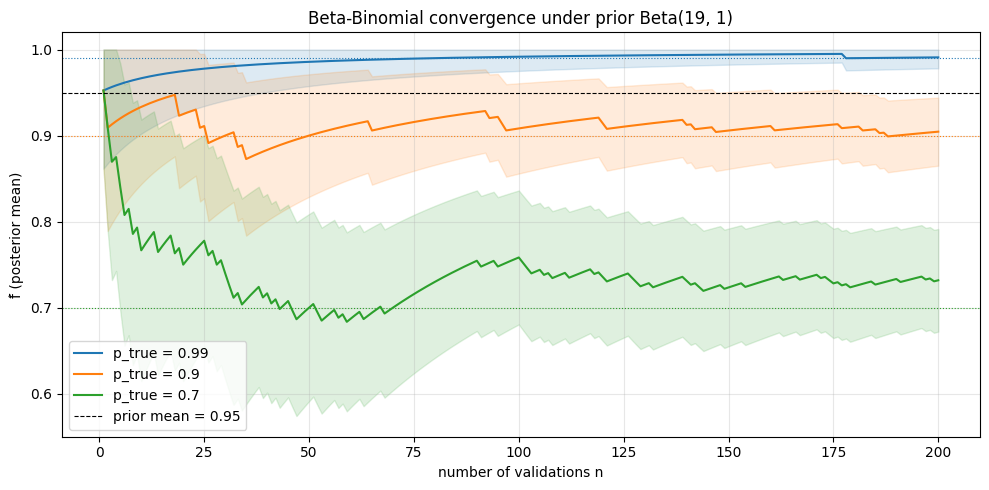

In [2]:
ALPHA0, BETA0 = 19.0, 1.0  # prior Beta(19, 1) ; f̂_0 = 0.95

def beta_post(alpha, beta):
    """Mean and approximate 95% CI (mean ± 2σ) for Beta(alpha, beta)."""
    mean = alpha / (alpha + beta)
    var = alpha * beta / ((alpha + beta) ** 2 * (alpha + beta + 1))
    std = np.sqrt(var)
    return mean, np.clip(mean - 2 * std, 0, 1), np.clip(mean + 2 * std, 0, 1)

def simulate_f_hat(p_true, n_steps, alpha0=ALPHA0, beta0=BETA0, rng=None):
    rng = rng or np.random.default_rng()
    a, b = alpha0, beta0
    means, los, his = [], [], []
    for _ in range(n_steps):
        if rng.uniform() < p_true:
            a += 1
        else:
            b += 1
        m, lo, hi = beta_post(a, b)
        means.append(m); los.append(lo); his.append(hi)
    return np.array(means), np.array(los), np.array(his)

n_max = 200
true_rates = [0.99, 0.90, 0.70]
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(10, 5))
for p in true_rates:
    means, lo, hi = simulate_f_hat(p, n_max, rng=rng)
    line, = ax.plot(np.arange(1, n_max + 1), means, label=f"p_true = {p}")
    ax.fill_between(np.arange(1, n_max + 1), lo, hi, alpha=0.15, color=line.get_color())
    ax.axhline(p, color=line.get_color(), linestyle=":", linewidth=0.8)

ax.axhline(ALPHA0 / (ALPHA0 + BETA0), color="black", linestyle="--",
           linewidth=0.8, label="prior mean = 0.95")
ax.set_xlabel("number of validations n")
ax.set_ylabel("f̂ (posterior mean)")
ax.set_title(f"Beta-Binomial convergence under prior Beta({int(ALPHA0)}, {int(BETA0)})")
ax.legend(loc="lower left")
ax.set_ylim(0.55, 1.02)
plt.tight_layout()
plt.show()

**Reading** : the bands represent the ~95% credible interval, which tightens as `1/√n`. For the agent at `p=0.70`, it takes nearly 100 validations for `f̂` to drop below 0.80. It is during this phase that a naive Sybil can farm the prior — hence the need for honeypots dedicated to cold-start.

## §2 — Sigmoid multiplier `M(f, d)`

Definition of the retained form:

$$M(f, d) = \sigma(k \cdot (f - f_0(d))) \cdot (1 + \gamma \cdot d), \qquad f_0(d) = f_{0,\max} - \delta \cdot d$$

Default parameters: `f₀_max = 0.90, δ = 0.10, k = 40, γ = 1`.

In [3]:
F0_MAX = 0.90
DELTA = 0.10
K_SIG = 40.0
GAMMA = 1.0

def M_sigmoid(f, d, f0_max=F0_MAX, delta=DELTA, k=K_SIG, gamma=GAMMA):
    f0 = f0_max - delta * d
    G = 1.0 / (1.0 + np.exp(-k * (f - f0)))
    return G * (1.0 + gamma * d)

### `M(f)` at fixed difficulty

We plot `M(f)` for `d ∈ {0.1, 0.5, 0.9}`. The curve at high `d` should be higher (difficulty bonus) **and** shifted to the left (sliding threshold) — this is the increased error tolerance on difficult tasks.

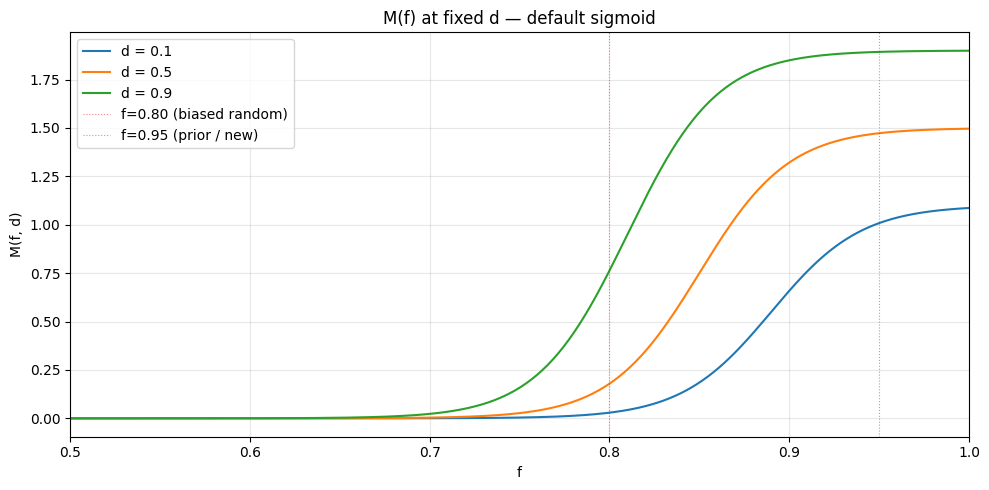

Target numerical values (sigmoid, defaults):
  M(f=0.8, d=0.0) = 0.0180
  M(f=0.8, d=0.5) = 0.1788
  M(f=0.8, d=1.0) = 1.0000
  M(f=0.9, d=0.0) = 0.5000
  M(f=0.9, d=0.5) = 1.3212
  M(f=0.9, d=1.0) = 1.9640
  M(f=0.95, d=0.0) = 0.8808
  M(f=0.95, d=0.5) = 1.4730
  M(f=0.95, d=1.0) = 1.9951
  M(f=0.99, d=0.0) = 0.9734
  M(f=0.99, d=0.5) = 1.4945
  M(f=0.99, d=1.0) = 1.9990


In [4]:
f_grid = np.linspace(0.5, 1.0, 500)
d_show = [0.1, 0.5, 0.9]

fig, ax = plt.subplots(figsize=(10, 5))
for d in d_show:
    ax.plot(f_grid, M_sigmoid(f_grid, d), label=f"d = {d}")
ax.axvline(0.80, color="red", linestyle=":", linewidth=0.8, alpha=0.5,
           label="f=0.80 (biased random)")
ax.axvline(0.95, color="green", linestyle=":", linewidth=0.8, alpha=0.5,
           label="f=0.95 (prior / new)")
ax.set_xlabel("f")
ax.set_ylabel("M(f, d)")
ax.set_title("M(f) at fixed d — default sigmoid")
ax.set_xlim(0.5, 1.0)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# A few target values to remember
print("Target numerical values (sigmoid, defaults):")
for f_val in [0.80, 0.90, 0.95, 0.99]:
    for d_val in [0.0, 0.5, 1.0]:
        print(f"  M(f={f_val}, d={d_val}) = {M_sigmoid(f_val, d_val):.4f}")

**Reading** :
- At `f = 0.80` (biased random) on an easy task (`d=0.1`) : `M ≈ 0.04`. Crushed: that's the goal.
- At `f = 0.80` on a difficult task (`d=0.9`) : `M` rises back toward ~1, but these tasks are rare in the flow. The increased tolerance does not save a fraudster who only rarely encounters difficult tasks.
- At `f = 0.95` (new or correctly honest agent) : `M` grows with `d`, the agent captures the difficulty bonus.
- At `f = 0.99` : saturates toward `(1+γd)`, little sensitive to residual variations in reliability.

### `M(d)` at fixed reliability

Conversely : `M(d)` at `f ∈ {0.70, 0.85, 0.95, 0.99}`. For an excellent agent (`f=0.99`), `M` should grow nearly linearly (the bonus). For a mediocre one (`f=0.70`), `M` should stay low even on difficult tasks.

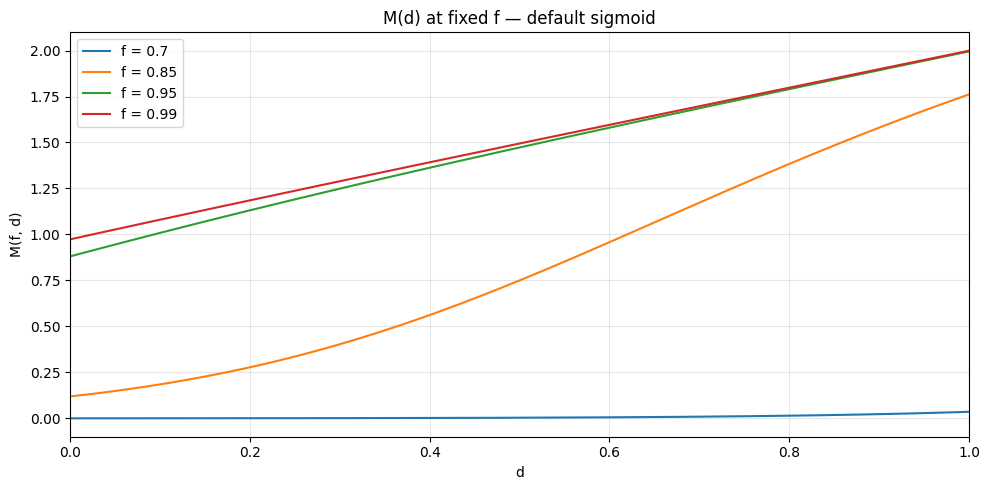

In [5]:
d_grid = np.linspace(0.0, 1.0, 500)
f_show = [0.70, 0.85, 0.95, 0.99]

fig, ax = plt.subplots(figsize=(10, 5))
for f in f_show:
    ax.plot(d_grid, M_sigmoid(np.full_like(d_grid, f), d_grid), label=f"f = {f}")
ax.set_xlabel("d")
ax.set_ylabel("M(f, d)")
ax.set_title("M(d) at fixed f — default sigmoid")
ax.set_xlim(0.0, 1.0)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 3D surface

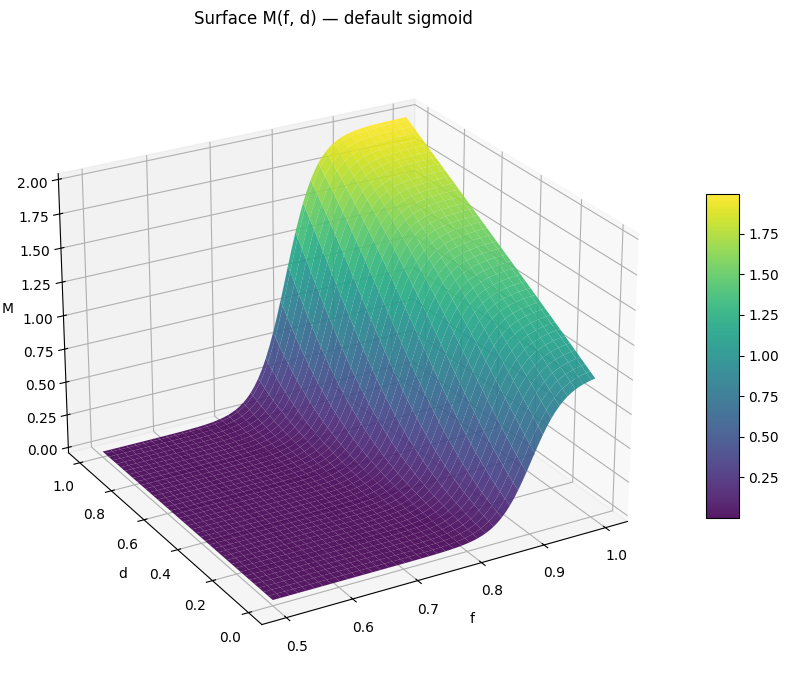

In [6]:
F, D = np.meshgrid(np.linspace(0.5, 1.0, 80), np.linspace(0.0, 1.0, 80))
Z = M_sigmoid(F, D)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(F, D, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
ax.set_xlabel("f")
ax.set_ylabel("d")
ax.set_zlabel("M")
ax.set_title("Surface M(f, d) — default sigmoid")
ax.view_init(elev=25, azim=-120)
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.tight_layout()
plt.show()

## §3 — Three validator profiles over 1000 tasks (sigmoid)

The strategic test. Stream of **1000 tasks** with difficulty `d_t ~ Beta(2, 5)` (skewed toward easy, mean ≈ 0.286). Three profiles:

| Profile | Acceptance strategy | Probability of correct vote |
|---|---|---|
| **honest** | takes every task | `p = 0.99` |
| **biased random** (att. 4) | takes every task | `p = 0.80` |
| **cherry-picker** (att. 5) | refuses tasks with `d ≥ 0.3` | `p = 0.995` |

Each agent starts with `f̂ = 0.95` (prior) and receives `M(f̂_before_update, d)` for each accepted task. Its reliability is updated according to Beta-Binomial.

**Note**: here we use the all-time Beta-Binomial `f̂` (for readability; at 1000 tasks the forgetting factor `ρ` would have little effect). For a behavior-switching test, the pseudo-count decay model from A.1 would be needed.

Expected target: **honest cumulative gain > cherry-picker > biased random**.

Distribution of d: mean 0.289, median 0.263
Tasks with d < 0.3 (acceptable by cherry-picker): 581 / 1000


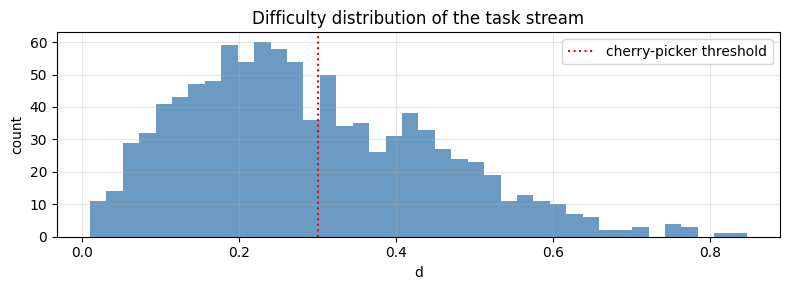

In [7]:
N_TASKS = 1000
rng = np.random.default_rng(123)
d_flow = rng.beta(2, 5, N_TASKS)

print(f"Distribution of d: mean {d_flow.mean():.3f}, median {np.median(d_flow):.3f}")
print(f"Tasks with d < 0.3 (acceptable by cherry-picker): {(d_flow < 0.3).sum()} / {N_TASKS}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(d_flow, bins=40, color="steelblue", alpha=0.8)
ax.axvline(0.3, color="red", linestyle=":", label="cherry-picker threshold")
ax.set_xlabel("d")
ax.set_ylabel("count")
ax.set_title("Difficulty distribution of the task stream")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
def simulate_validator(p_correct, accept_d_fn, M_fn, d_flow, rng):
    a, b = ALPHA0, BETA0
    f_hat_trace = np.empty(len(d_flow))
    cum_reward_trace = np.empty(len(d_flow))
    cum = 0.0
    ds_taken = []
    n_taken = 0
    for t, d in enumerate(d_flow):
        if accept_d_fn(d):
            f_hat_pre = a / (a + b)
            r = float(M_fn(np.array([f_hat_pre]), np.array([d]))[0])
            cum += r
            n_taken += 1
            ds_taken.append(d)
            if rng.uniform() < p_correct:
                a += 1
            else:
                b += 1
        f_hat_trace[t] = a / (a + b)
        cum_reward_trace[t] = cum
    return {
        "f_hat": f_hat_trace,
        "cum_reward": cum_reward_trace,
        "ds_taken": np.array(ds_taken),
        "n_taken": n_taken,
        "final_cum": cum,
    }

profiles = {
    "honest (p=0.99)":            dict(p=0.99,  accept=lambda d: True),
    "biased random (p=0.80)":     dict(p=0.80,  accept=lambda d: True),
    "cherry-picker (p=0.995, d<0.3)": dict(p=0.995, accept=lambda d: d < 0.3),
}

results = {}
for prof_name, cfg in profiles.items():
    rng_local = np.random.default_rng(7)
    results[prof_name] = simulate_validator(
        cfg["p"], cfg["accept"], M_sigmoid, d_flow, rng_local
    )

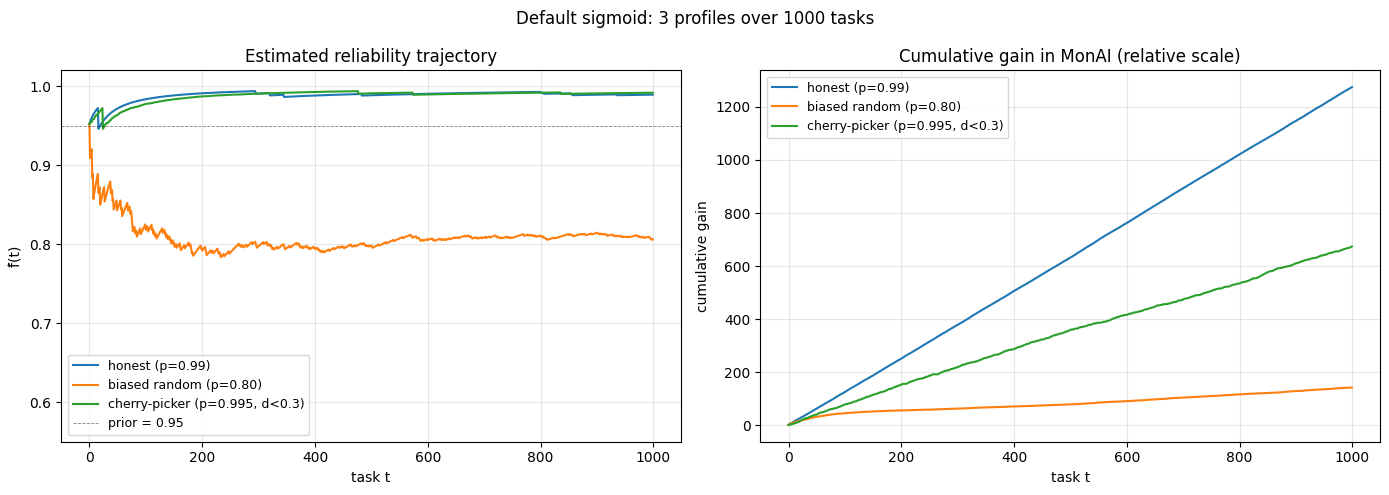

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(N_TASKS)

for prof_name in profiles:
    res = results[prof_name]
    axes[0].plot(x, res["f_hat"], label=prof_name)
    axes[1].plot(x, res["cum_reward"], label=prof_name)

axes[0].axhline(0.95, color="black", linestyle="--", linewidth=0.6, alpha=0.5,
                label="prior = 0.95")
axes[0].set_xlabel("task t")
axes[0].set_ylabel("f̂(t)")
axes[0].set_title("Estimated reliability trajectory")
axes[0].set_ylim(0.55, 1.02)
axes[0].legend(loc="lower left", fontsize=9)

axes[1].set_xlabel("task t")
axes[1].set_ylabel("cumulative gain")
axes[1].set_title("Cumulative gain in MonAI (relative scale)")
axes[1].legend(loc="upper left", fontsize=9)

fig.suptitle("Default sigmoid: 3 profiles over 1000 tasks")
plt.tight_layout()
plt.show()

In [10]:
# Numerical summary table
print(f"{'Profile':<35} {'tasks taken':>14} {'d̄ taken':>9} {'final f̂':>9} {'final gain':>12}")
print("-" * 85)
for prof_name in profiles:
    r = results[prof_name]
    d_mean = r["ds_taken"].mean() if len(r["ds_taken"]) else float("nan")
    print(f"{prof_name:<35} {r['n_taken']:>14d} {d_mean:>9.3f} "
          f"{r['f_hat'][-1]:>9.4f} {r['final_cum']:>12.2f}")

honest = results["honest (p=0.99)"]["final_cum"]
for prof_name in profiles:
    ratio = results[prof_name]["final_cum"] / honest
    print(f"{prof_name:<40} gain ratio / honest = {ratio:.3f}")

Profile                                tasks taken  d̄ taken  final f̂   final gain
-------------------------------------------------------------------------------------
honest (p=0.99)                               1000     0.289    0.9892      1274.52
biased random (p=0.80)                        1000     0.289    0.8059       141.53
cherry-picker (p=0.995, d<0.3)                 581     0.179    0.9917       673.76
honest (p=0.99)                          gain ratio / honest = 1.000
biased random (p=0.80)                   gain ratio / honest = 0.111
cherry-picker (p=0.995, d<0.3)           gain ratio / honest = 0.529


**Reading** : the expected hierarchy **honest > cherry-picker > biased random** should come out clearly.
- The biased random sees its `f̂` drop toward 0.80 and its gain stifled (the sigmoid crushes it).
- The cherry-picker keeps a near-perfect `f̂` but only harvests on easy tasks → ~50% of the honest agent's gain.
- The honest agent captures everything: the difficulty bonus + saturated reliability.

If the calibration lets the cherry-picker catch up with the honest agent, then `γ` (difficulty bonus) is too low — increase `γ`, or impose a minimum hard/easy payment ratio at the system level (cf. `../securite/05-modele-de-menace-et-defenses.md` §Attack 5).

---

# Annexes — alternative forms not retained by default

Kept in case empirical calibration in phase 0 invalidates the sigmoid.

## §4 — Annex: qualitative comparison of the 3 `M(f, d)` candidates

We visually compare the retained sigmoid with the quadratic exponential and the power law with hard threshold.

In [11]:
# Definitions of the two alternative candidates
def M_exp(f, d, lambda0=100.0, mu=0.8, gamma=GAMMA):
    lam = lambda0 * (1.0 - mu * d)
    G = np.exp(-lam * (1.0 - f) ** 2)
    return G * (1.0 + gamma * d)

def M_power(f, d, fmin_max=0.80, delta=0.10, p=2.0, gamma=GAMMA):
    fmin = fmin_max - delta * d
    raw = (f - fmin) / (1.0 - fmin)
    G = np.where(f > fmin, np.clip(raw, 0, 1) ** p, 0.0)
    return G * (1.0 + gamma * d)

candidates = [("Sigmoid (default)", M_sigmoid),
              ("Quadratic exp. (annex)", M_exp),
              ("Power law (annex)", M_power)]

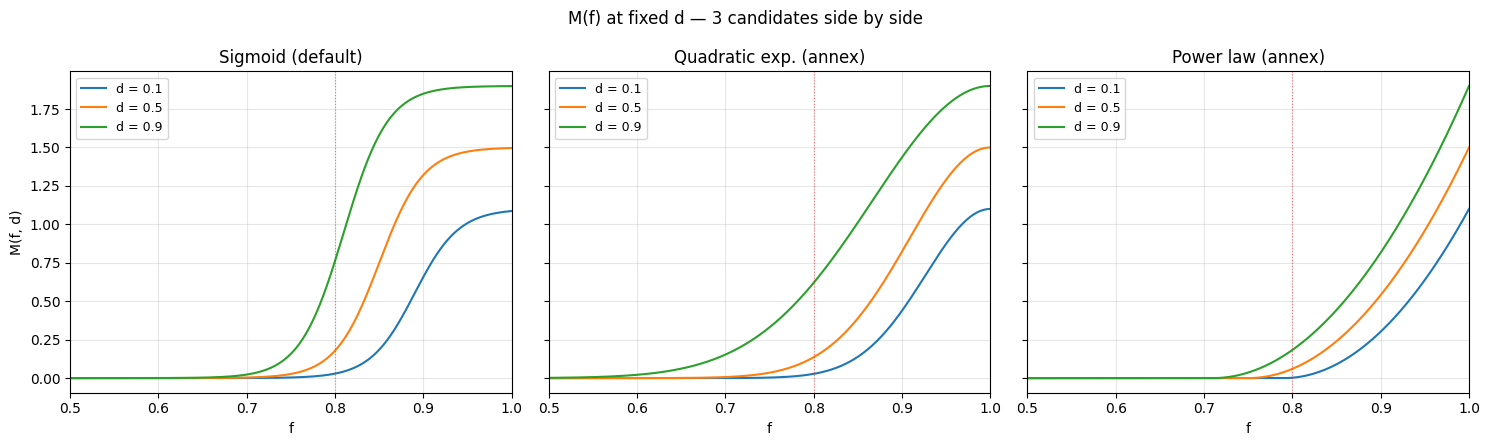

In [12]:
# Comparison M(f) at fixed d
f_grid = np.linspace(0.5, 1.0, 500)
d_show = [0.1, 0.5, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (name, M_fn) in zip(axes, candidates):
    for d in d_show:
        ax.plot(f_grid, M_fn(f_grid, d), label=f"d = {d}")
    ax.axvline(0.80, color="red", linestyle=":", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("f")
    ax.set_title(name)
    ax.set_xlim(0.5, 1.0)
    ax.legend(loc="upper left", fontsize=9)
axes[0].set_ylabel("M(f, d)")
fig.suptitle("M(f) at fixed d — 3 candidates side by side")
plt.tight_layout()
plt.show()

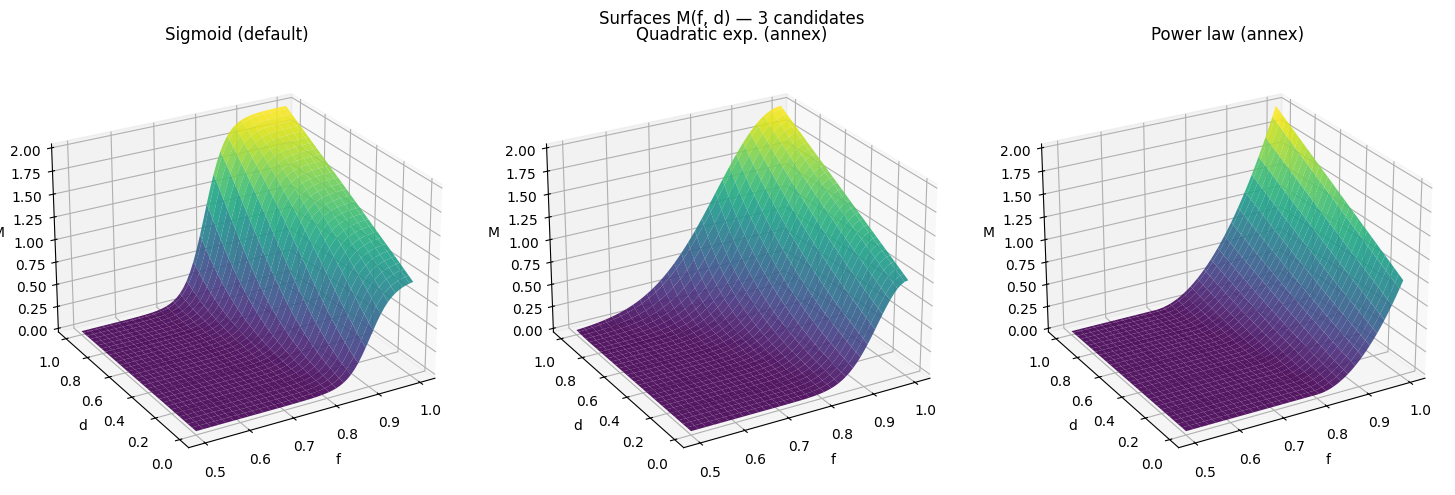

In [13]:
# 3D surfaces of the 3 candidates
F, D = np.meshgrid(np.linspace(0.5, 1.0, 60), np.linspace(0.0, 1.0, 60))

fig = plt.figure(figsize=(15, 5))
for i, (name, M_fn) in enumerate(candidates):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    Z = M_fn(F, D)
    ax.plot_surface(F, D, Z, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)
    ax.set_xlabel("f"); ax.set_ylabel("d"); ax.set_zlabel("M")
    ax.set_title(name)
    ax.view_init(elev=25, azim=-120)
fig.suptitle("Surfaces M(f, d) — 3 candidates")
plt.tight_layout()
plt.show()

In [14]:
# Comparative simulation of the 3 candidates on the same 3 profiles
annex_results = {}
for M_name, M_fn in candidates:
    annex_results[M_name] = {}
    for prof_name, cfg in profiles.items():
        rng_local = np.random.default_rng(7)
        annex_results[M_name][prof_name] = simulate_validator(
            cfg["p"], cfg["accept"], M_fn, d_flow, rng_local
        )

print(f"{'M candidate':<28} {'Profile':<32} {'final gain':>12} {'ratio/honest':>15}")
print("-" * 95)
for M_name, _ in candidates:
    honest_gain = annex_results[M_name]["honest (p=0.99)"]["final_cum"]
    for prof_name in profiles:
        g = annex_results[M_name][prof_name]["final_cum"]
        print(f"{M_name:<28} {prof_name:<32} {g:>12.2f} {g/honest_gain:>15.3f}")
    print()

M candidate                  Profile                            final gain    ratio/honest
-----------------------------------------------------------------------------------------------
Sigmoid (default)            honest (p=0.99)                       1274.52           1.000
Sigmoid (default)            biased random (p=0.80)                 141.53           0.111
Sigmoid (default)            cherry-picker (p=0.995, d<0.3)         673.76           0.529

Quadratic exp. (annex)       honest (p=0.99)                       1270.15           1.000
Quadratic exp. (annex)       biased random (p=0.80)                 102.29           0.081
Quadratic exp. (annex)       cherry-picker (p=0.995, d<0.3)         671.03           0.528

Power law (annex)            honest (p=0.99)                       1157.98           1.000
Power law (annex)            biased random (p=0.80)                  48.12           0.042
Power law (annex)            cherry-picker (p=0.995, d<0.3)         606.98         

**Reading** :
- The three candidates produce the same hierarchy `honest > cherry-picker > biased random`.
- The power law penalizes the biased random the most harshly (~3-4% of the honest gain); the sigmoid penalizes it moderately (~10%); the quadratic exp. in the middle.
- The cherry-picker/honest ratio is ≈ 0.53 in all three cases — the defense against cherry-picking does not depend on the choice of `M`, it depends on the fact that the cherry-picker refuses 42% of tasks and misses the `(1+γd)` bonus.

This robustness to the choice of `M` is reassuring: the retained sigmoid is dominated on the penalty of the biased random but remains coherent in orders of magnitude. The choice is justified on the interpretability of the threshold and differentiability rather than on raw severity.

## §5 — Annex: three equivalent definitions of `d`

For binary votes, the three difficulty formulas are monotonic with respect to each other. Quick visualization.

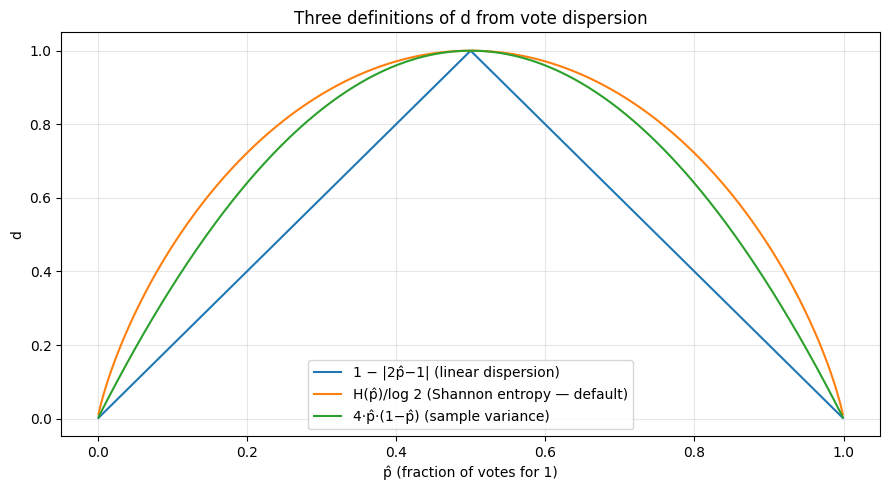

In [15]:
p_grid = np.linspace(0.001, 0.999, 500)

d_linear = 1 - np.abs(2 * p_grid - 1)
d_entropy = -(p_grid * np.log2(p_grid) + (1 - p_grid) * np.log2(1 - p_grid))
d_variance = 4 * p_grid * (1 - p_grid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(p_grid, d_linear,   label="1 − |2p̂−1| (linear dispersion)")
ax.plot(p_grid, d_entropy,  label="H(p̂)/log 2 (Shannon entropy — default)")
ax.plot(p_grid, d_variance, label="4·p̂·(1−p̂) (sample variance)")
ax.set_xlabel("p̂ (fraction of votes for 1)")
ax.set_ylabel("d")
ax.set_title("Three definitions of d from vote dispersion")
ax.legend()
plt.tight_layout()
plt.show()

**Reading**: the three curves peak at `p̂ = 0.5` and touch 0 at the extremes. For `K = 2`, the choice among them only affects the exact "shape" of `M(f, d)`. Shannon entropy is retained by default for its direct generalization to `K > 2` verdicts ("compliant / partial / non-compliant").

## Takeaways

1. **Prior `Beta(19, 1)`** is suitable for `p_true ∈ [0.9, 1]`; leaves an initial farming window of about 50-100 validations for an agent at `p=0.7-0.8`. Planned mitigation: honeypots dedicated to cold-start (cf. `../design/03-identite-et-reputation.md` §Route A).

2. **Retained sigmoid**: `M(f, d) = σ(40·(f − 0.90 + 0.10·d)) · (1 + d)` produces the expected hierarchy `honest > cherry-picker > biased random` with respective ratios ~1.0 / ~0.53 / ~0.11. Sufficient margins; calibration of `γ` (difficulty bonus) to be coordinated with the easy/hard ratio at the flow level.

3. **Robustness to the choice of `M`**: the three functional candidates produce the same qualitative hierarchy; the sigmoid is retained on the interpretability of the threshold and differentiability, not on raw severity.

4. **`d` (Shannon entropy)**: equivalent to alternatives for `K = 2`, retained for the generalization to `K > 2`.

5. All values (`α₀=19, β₀=1, k=40, f₀_max=0.90, δ=0.10, γ=1`) are **reasonable starting points**, to be recalibrated in systemic simulation in phase 0 (cf. `../operations/06-questions-ouvertes-et-roadmap.md`).